In [25]:
from sklearn.metrics import recall_score, precision_score
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [26]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

In [27]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h","HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))

Shape: (1383922, 50)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [28]:
# --- Time-based split ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class","y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as feature (we already have time features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (922720, 47) (228784, 47) (232418, 47)


In [29]:
from catboost import CatBoostClassifier

# ============================================================
# C) Two-Stage CatBoost
# Stage 1: Low (0) vs Not-Low (1 or 2)
# Stage 2: Medium (1) vs High (2)  [train only on non-zero]
# Thresholds:
#   tau1 for P(NotLow)
#   tau2 for P(High | NotLow)
# ============================================================


# ---- Stage 1 labels: not-low (1/2) vs low (0)
y1_train = (y_train != 0).astype(int)
y1_val   = (y_val != 0).astype(int)
y1_test  = (y_test != 0).astype(int)

# ---- Stage 2 training subset: only where y in {1,2}
train_nz = (y_train != 0)
val_nz   = (y_val != 0)
test_nz  = (y_test != 0)

X2_train = X_train.loc[train_nz].copy()
y2_train = (y_train.loc[train_nz] == 2).astype(int)   # 1 = High, 0 = Medium
X2_val   = X_val.loc[val_nz].copy()
y2_val   = (y_val.loc[val_nz] == 2).astype(int)
X2_test  = X_test.loc[test_nz].copy()
y2_test  = (y_test.loc[test_nz] == 2).astype(int)

# ---- Cat features: use names (more robust than indices)
cat_cols = [c for c in X_train.columns if c.startswith("cat_")] 
cat_features_names = [c for c in cat_cols if c in X_train.columns]

# ---- Binary class weights for stage 1 and stage 2 (balanced)
def balanced_binary_weights(ybin):
    # ybin in {0,1}
    counts = pd.Series(ybin).value_counts().to_dict()
    n = len(ybin)
    w0 = n / (2 * counts.get(0, 1))
    w1 = n / (2 * counts.get(1, 1))
    return [w0, w1]

cw1 = balanced_binary_weights(y1_train)
cw2 = balanced_binary_weights(y2_train)

print("Stage1 counts:", pd.Series(y1_train).value_counts().to_dict(), "class_weights:", cw1)
print("Stage2 counts:", pd.Series(y2_train).value_counts().to_dict(), "class_weights:", cw2)

# ---- Train Stage 1
stage1 = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="Logloss",
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=42,
    verbose=200,
    class_weights=cw1,
    od_type="Iter",
    od_wait=200
)

stage1.fit(
    X_train, y1_train,
    cat_features=cat_features_names,
    eval_set=(X_val, y1_val),
    use_best_model=True
)

# ---- Train Stage 2 (only non-zero subset)
stage2 = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="Logloss",
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=42,
    verbose=200,
    class_weights=cw2,
    od_type="Iter",
    od_wait=200
)

stage2.fit(
    X2_train, y2_train,
    cat_features=cat_features_names,
    eval_set=(X2_val, y2_val),
    use_best_model=True
)

# ---- Tune tau2 on Stage 2 validation subset (Medium vs High)
def choose_tau_binary_by_recall(p_pos, y_true_pos, target_recall=0.80):
    taus = np.linspace(0.01, 0.99, 99)
    rows = []
    for tau in taus:
        pred = (p_pos >= tau).astype(int)
        rec = recall_score(y_true_pos, pred, zero_division=0)
        prec = precision_score(y_true_pos, pred, zero_division=0)
        rows.append((tau, rec, prec))
    tab = pd.DataFrame(rows, columns=["tau","recall","precision"])
    cand = tab[tab["recall"] >= target_recall]
    if len(cand) == 0:
        best = tab.sort_values(["recall","precision"], ascending=False).iloc[0]
    else:
        best = cand.sort_values(["precision","recall"], ascending=False).iloc[0]
    return float(best["tau"]), tab

p2_val = stage2.predict_proba(X2_val)[:, 1]   # P(high | not-low)
tau2, tau2_table = choose_tau_binary_by_recall(p2_val, y2_val, target_recall=0.80)
print("Chosen tau2 (Stage2 High):", tau2)

# ---- Tune tau1 on Stage 1 validation (Low vs Not-Low)
p1_val = stage1.predict_proba(X_val)[:, 1]    # P(not-low)
tau1, tau1_table = choose_tau_binary_by_recall(p1_val, y1_val, target_recall=0.85)
print("Chosen tau1 (Stage1 NotLow):", tau1)

# ---- Combine predictions on any split
def two_stage_predict(X_any):
    # Stage 1: P(not-low) for all rows
    p_notlow = stage1.predict_proba(X_any)[:, 1]
    pred = np.zeros(len(X_any), dtype=int)  # default Low (0)

    # rows considered not-low
    idx_notlow = np.where(p_notlow >= tau1)[0]
    pred[idx_notlow] = 1  # default Medium (1)

    # Stage 2 only on not-low subset
    if len(idx_notlow) > 0:
        X_sub = X_any.iloc[idx_notlow]
        p_high = stage2.predict_proba(X_sub)[:, 1]  # length = len(idx_notlow)

        idx_high_local = np.where(p_high >= tau2)[0]  # indices within subset
        idx_high_global = idx_notlow[idx_high_local]  # map back to global indices

        pred[idx_high_global] = 2

    return pred 

# ---- Evaluate on Val/Test
eval_multiclass = lambda y_true, y_pred, name: {
    "model": name,
    "recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
    "precision": precision_score(y_true, y_pred, average='macro', zero_division=0)
}
pred_val_2stage  = two_stage_predict(X_val)
metrics_val_2s   = eval_multiclass(y_val, pred_val_2stage,
                                   name=f"Two-Stage CatBoost (tau1={tau1:.2f}, tau2={tau2:.2f}) - Val")

pred_test_2stage = two_stage_predict(X_test)
metrics_test_2s  = eval_multiclass(y_test, pred_test_2stage,
                                   name=f"Two-Stage CatBoost (tau1={tau1:.2f}, tau2={tau2:.2f}) - Test")
# ---- Save artifacts
OUT_S1 = DATA_DIR / "two_stage_catboost_stage1_notlow.cbm"
OUT_S2 = DATA_DIR / "two_stage_catboost_stage2_high.cbm"
stage1.save_model(str(OUT_S1))
stage2.save_model(str(OUT_S2))

with open(DATA_DIR / "two_stage_tau1.txt", "w") as f:
    f.write(str(tau1))
with open(DATA_DIR / "two_stage_tau2.txt", "w") as f:
    f.write(str(tau2))

print("Saved:", OUT_S1)
print("Saved:", OUT_S2)

# Add to results summary table at end of notebook
results = []
results.append({"model": f"Two-Stage CatBoost tau1={tau1:.2f} tau2={tau2:.2f}", **metrics_test_2s})

Stage1 counts: {0: 823183, 1: 99537} class_weights: [0.5604586100539005, 4.635060329324774]
Stage2 counts: {0: 86350, 1: 13187} class_weights: [0.5763578459756804, 3.774057784181391]
0:	learn: 0.6855707	test: 0.6854140	best: 0.6854140 (0)	total: 153ms	remaining: 5m 6s
200:	learn: 0.5969162	test: 0.5958666	best: 0.5958666 (200)	total: 29.5s	remaining: 4m 23s
400:	learn: 0.5850747	test: 0.5873280	best: 0.5873280 (400)	total: 1m	remaining: 4m 1s
600:	learn: 0.5772566	test: 0.5837947	best: 0.5837909 (598)	total: 1m 28s	remaining: 3m 26s
800:	learn: 0.5712301	test: 0.5826665	best: 0.5826252 (787)	total: 1m 57s	remaining: 2m 56s
1000:	learn: 0.5659942	test: 0.5821354	best: 0.5821226 (980)	total: 2m 28s	remaining: 2m 28s
1200:	learn: 0.5609801	test: 0.5820341	best: 0.5819401 (1086)	total: 2m 59s	remaining: 1m 59s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5819401095
bestIteration = 1086

Shrink model to first 1087 iterations.
0:	learn: 0.6892833	test: 0.6898472	best:

In [30]:
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    rec_high = recall_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    prec_high = precision_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec_high), 4))
    print("High-risk precision:", round(float(prec_high), 4))
    print("\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")
    return {
        "recall_0": rec[0], "recall_1": rec[1], "recall_2": rec[2],
        "macro_recall": macro_rec, "recall_high": rec_high, "precision_high": prec_high
    }


=== Two-Stage - Val ===
Per-class recall [0,1,2]: [0.5005 0.2279 0.8031]
Macro recall: 0.5105
High-risk recall: 0.8031
High-risk precision: 0.0336

               precision    recall  f1-score   support

           0     0.9668    0.5005    0.6596    204791
           1     0.1041    0.2279    0.1429     20758
           2     0.0336    0.8031    0.0645      3235

    accuracy                         0.4801    228784
   macro avg     0.3682    0.5105    0.2890    228784
weighted avg     0.8754    0.4801    0.6043    228784



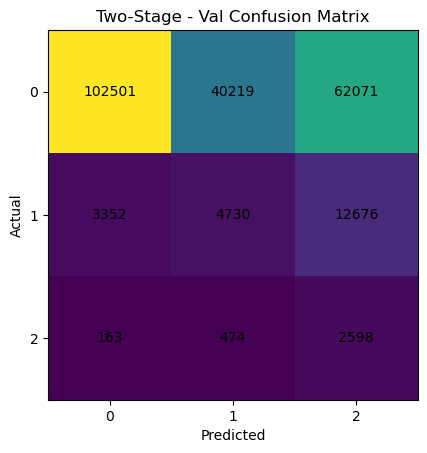


=== Two-Stage - Test ===
Per-class recall [0,1,2]: [0.4768 0.1921 0.8546]
Macro recall: 0.5078
High-risk recall: 0.8546
High-risk precision: 0.0332

               precision    recall  f1-score   support

           0     0.9689    0.4768    0.6391    207818
           1     0.0964    0.1921    0.1284     21189
           2     0.0332    0.8546    0.0638      3411

    accuracy                         0.4564    232418
   macro avg     0.3662    0.5078    0.2771    232418
weighted avg     0.8756    0.4564    0.5841    232418



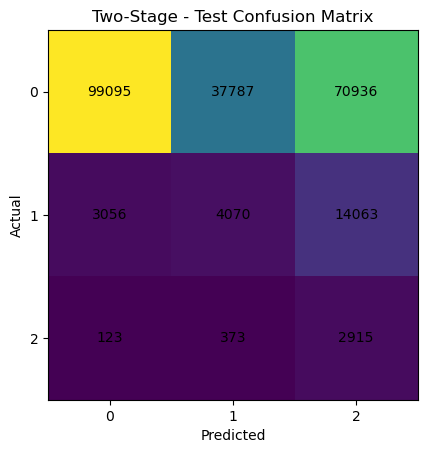

{'recall_0': np.float64(0.47683550029352606),
 'recall_1': np.float64(0.1920807966397659),
 'recall_2': np.float64(0.8545880973321607),
 'macro_recall': 0.5078347980884842,
 'recall_high': 0.8545880973321607,
 'precision_high': 0.03315740382646677}

In [31]:
pred_val_2stage = two_stage_predict(X_val)
eval_multiclass(y_val, pred_val_2stage, "Two-Stage - Val")

pred_test_2stage = two_stage_predict(X_test)
eval_multiclass(y_test, pred_test_2stage, "Two-Stage - Test")